# Estimate a TICA Model

This notebook fits a [TICA](https://deeptime-ml.github.io/latest/api/generated/deeptime.decomposition.TICA.html) (Time-lagged Independent Component Analysis) model on pairwise $C_{\alpha}-C_{\alpha}$ distances computed from a reference MD trajectory of BBA. The same procedure can be done for all fast-folding proteins by changing `protein` and `h5_path`.

---

**Prerequisites**: MD trajectories of the fast-folding proteins ([Lindorff-Larsen et al., Science 2011](https://www.science.org/doi/10.1126/science.1208351)) are proprietary and cannot be redistributed. Please contact the authors to request access for research purposes.

In [1]:
from pathlib import Path

protein  = "bba"
h5_path  = Path("/path/to/fast_folders/trajectories/bba.h5")   # C_{\alpha} trajectory in HDF5 format
out_dir  = Path("/path/to/fast_folders/reference_TICA")        # where to save the TICA model

# TICA hyperparameters
lagtime       = 10
frame_spacing = 0.2
lag_frames    = int(lagtime/frame_spacing)
n_components  = 4

# Histogram grid settings
num_bins = 50

In [2]:
import pickle
import numpy as np
import h5py

from deeptime.decomposition import TICA

from platito.utils.tica_utils import distances

In [3]:
# Load coordinates
with h5py.File(h5_path, "r") as f:
    md_coords = np.array(f["ca_xyz_0000"])  # [T, L, 3]

print(f"Loaded {len(md_coords):,} frames, {md_coords.shape[1]} residues")

Loaded 1,114,545 frames, 28 residues


In [4]:
# Compute pairwise C_{\alpha} distances in batches (reduce batch_size if you run out of memory)
batch_size = 50000

ca_distances = np.concatenate(
    [
        distances(md_coords[start : start + batch_size])
        for start in range(0, len(md_coords), batch_size)
    ],
    axis=0,
)  # [T, n_pairs]

In [5]:
tica_model = TICA(lagtime=lag_frames, dim=n_components).fit(ca_distances).fetch_model()
projections = tica_model.transform(ca_distances)[:, :2]

In [6]:
# Compute histogram bin edges
xedges = np.linspace(projections[:, 0].min(), projections[:, 0].max(), num_bins + 1)
yedges = np.linspace(projections[:, 1].min(), projections[:, 1].max(), num_bins + 1)

Visualize the free energy surface.

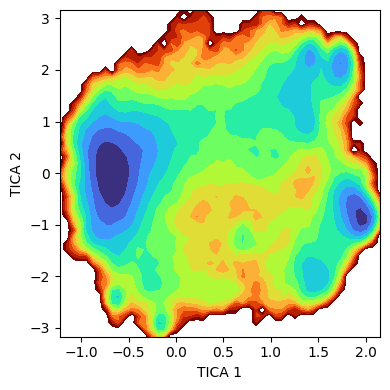

In [7]:
import matplotlib.pyplot as plt
from platito.utils.bioemu_utils import plot_free_energy_on_axes

fig, ax = plt.subplots(figsize=(4, 4))

plot_free_energy_on_axes(
    ax, 
    projections,
    num_bins=num_bins, 
    max_energy=10.0, 
    levels=15, 
    kBT=1.0,
    x_range=(xedges[0], xedges[-1]),
    y_range=(yedges[0], yedges[-1]),
)

ax.set_xlabel("TICA 1")
ax.set_ylabel("TICA 2")
plt.tight_layout()
plt.show()

Save the estimated TICA model.

In [8]:
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f"{protein}.pkl"

with open(out_path, "wb") as f:
    pickle.dump(
        {
            "tica": tica_model,
            "tica_xedges": xedges,
            "tica_yedges": yedges,
        },
        f,
    )